📊 Smartphone Procurement Analytics – Data Quality & Visualization Pipeline

This project focuses on supporting a procurement function in evaluating mobile device options for employees through a data analytics and visualization workflow.

🔍 Project Overview
A data pipeline was developed to ingest, clean, and analyse smartphone data from CSV sources, enabling comparison of key device attributes against price. The project emphasises code quality, reusability, and production readiness.

⚙️ Key Features
	•	Code Refactoring
	•	Eliminated duplicated logic to align with DRY principles
	•	Standardised column handling using reusable helper functions (e.g. column_to_label())
	•	Data Cleaning & Transformation
	•	Processed raw smartphone data into a structured format for analysis
	•	Implemented handling of missing values to ensure data integrity
	•	Data Visualization
	•	Built a flexible plotting function to analyse relationships between selected variables and price
	•	Enabled dynamic input of variables for comparative analysis
	•	Testing & Validation
	•	Developed and aligned unit tests (pytest) with transformation logic
	•	Ensured correct handling of NaN values in cleaned datasets
	•	Achieved a fully passing test suite (ExitCode.OK) for production readiness

📈 Outcome
	•	Improved maintainability and scalability of the data pipeline
	•	Increased reliability of data through aligned testing and validation
	•	Enabled data-driven evaluation of smartphone options for procurement decisions

In [1]:
# Import required packages
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pytest
import ipytest

Matplotlib is building the font cache; this may take a moment.


In [ ]:
def prepare_smartphone_data(file_path):
    """
    To prepare the smartphone data for visualization, a number of transformations 
    will be applied after reading in the raw DataFrame to memory, including:
        - reducing the number of columns to only those needed for later analysis
        - removing records without a battery_capacity value
        - divide the price column by 100 to find the dollar amount
    
    :param file_path: the file path where the raw smartphone data is stored
    :return: a cleaned dataset having had the operations above applied to it
    """
    
    if os.path.exists(file_path):
        rawdata = pd.read_csv(file_path) 
    else:
        raise Exception(f"File containing smartphone data not found at path {file_path}")

    columns_to_keep = [
        "brand_name",
        "os",
        "price",
        "avg_rating",
        "processor_speed",
        "battery_capacity",
        "screen_size"
    ]
    
    trimmeddata = rawdata.loc[:, columns_to_keep]


    # Remove records without a battery_capacity value
    reduceddata = trimmeddata.dropna(subset=["battery_capacity", "os"])
    
    # Divide the price column by 100 to find the dollar amount
    reduceddata["price"] = reduceddata["price"] / 100
    
    return reduceddata

# Call the function
cleaned_data = prepare_smartphone_data("./data/smartphones.csv")

/var/folders/rr/8gn7fy7d7g7gdxbd4mnlt3hr0000gn/T/ipykernel_5332/3812526127.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reduceddata["price"]=reduceddata["price"]/ 100


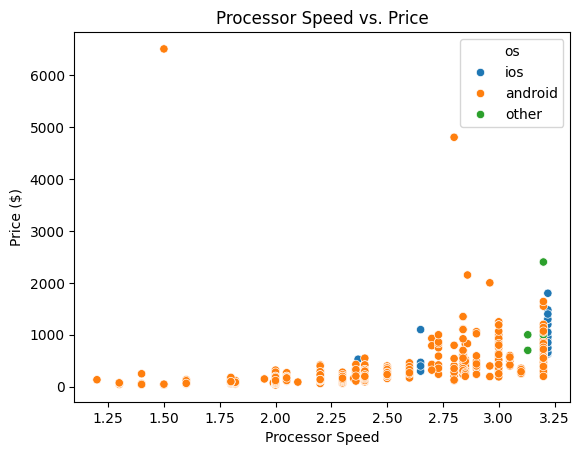

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

def column_to_label(column_name):
    """
    Converts a column name in a pandas DataFrame to a string that can be
    used as a label in a plot.
    
    :param column_name: string containing original column name
    :return: string that is ready to be presented on a plot
    """
    
    # Validate that column_name is a string
    if isinstance(column_name, str):
        return " ".join(column_name.split("_")).title()
    
    # If the value provided is not a string, raise an Exception
    else:
        raise Exception("Please makes sure to pass a value of type 'str'.")


def visualize_versus_price(clean_data, x):
    """
    Use seaborn and matplotlib to identify a pattern between avg_rating and 
    battery_capacity.
    
    :param clean_data: a pandas DataFrame containing cleaned smartphone data
    :param x: variable to be plotted on the x-axis
    :return: None
    """
    
    # Create the scatterplot
    sns.scatterplot(x=x, y="price", data=clean_data, hue="os")
    
    # Add x and y labels
    plt.xlabel(column_to_label(x))
    plt.ylabel("Price ($)")
    
    # Add a title to the plot
    plt.title(f"{column_to_label(x)} vs. Price")
    
    
# Call the visualize_versus_price function
visualize_versus_price(cleaned_data, "processor_speed")


In [4]:
ipytest.config.rewrite_asserts = True
__file__ = "notebook.ipynb"

# Create a clean DataFrame fixture
@pytest.fixture()
def clean_smartphone_data():
    return prepare_smartphone_data("./data/smartphones.csv")

def test_nan_values(clean_smartphone_data):
    """
    Test for no NaN value for "battery_capacity" or "os"
    """
    # Assert there are no NaN value in "battery_capacity" or "os"
    assert clean_smartphone_data["battery_capacity"].isna().sum() == 0
    assert clean_smartphone_data["os"].isna().sum() == 0

ipytest.run("-qq")

.                                                                                            [100%]
========================================= warnings summary =========================================
t_d665fd651d2f4071b30e910c4c32c951.py::test_nan_values
  /var/folders/rr/8gn7fy7d7g7gdxbd4mnlt3hr0000gn/T/ipykernel_5332/3812526127.py:35: SettingWithCopyWarning: 
  A value is trying to be set on a copy of a slice from a DataFrame.
  Try using .loc[row_indexer,col_indexer] = value instead
  
  See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
    reduceddata["price"]=reduceddata["price"]/ 100

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html


<ExitCode.OK: 0>